1. Data Loading

In [46]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor

In [47]:
import warnings
warnings.filterwarnings("ignore")

In [48]:
df = pd.read_csv(r'C:\Users\juman\OneDrive\Desktop\Prog\car_price_prediction.csv.zip')

In [49]:
df.head(20)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
7,45816158,549,751,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,216118 km,4.0,Automatic,Front,04-May,Left wheel,Grey,12
8,45641395,1098,394,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
9,45756839,26657,-,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


2. Data Cleaning

In [50]:
df = df.drop(["ID","Color","Wheel" ,"Airbags","Cylinders","Doors","Model"], axis=1)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Price             19237 non-null  int64 
 1   Levy              19237 non-null  object
 2   Manufacturer      19237 non-null  object
 3   Prod. year        19237 non-null  int64 
 4   Category          19237 non-null  object
 5   Leather interior  19237 non-null  object
 6   Fuel type         19237 non-null  object
 7   Engine volume     19237 non-null  object
 8   Mileage           19237 non-null  object
 9   Gear box type     19237 non-null  object
 10  Drive wheels      19237 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.6+ MB


In [52]:
df.duplicated().sum()

np.int64(3565)

In [53]:
df=df.drop_duplicates()

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df.isnull().sum()

Price               0
Levy                0
Manufacturer        0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Gear box type       0
Drive wheels        0
dtype: int64

In [56]:
df.head(40)

,Price,Levy,Manufacturer,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels
0,13328,1399,LEXUS,2010,Jeep,Yes,Hybrid,3.5,186005 km,Automatic,4x4
1,16621,1018,CHEVROLET,2011,Jeep,No,Petrol,3,192000 km,Tiptronic,4x4
2,8467,-,HONDA,2006,Hatchback,No,Petrol,1.3,200000 km,Variator,Front
3,3607,862,FORD,2011,Jeep,Yes,Hybrid,2.5,168966 km,Automatic,4x4
4,11726,446,HONDA,2014,Hatchback,Yes,Petrol,1.3,91901 km,Automatic,Front
5,39493,891,HYUNDAI,2016,Jeep,Yes,Diesel,2,160931 km,Automatic,Front
6,1803,761,TOYOTA,2010,Hatchback,Yes,Hybrid,1.8,258909 km,Automatic,Front
7,549,751,HYUNDAI,2013,Sedan,Yes,Petrol,2.4,216118 km,Automatic,Front
8,1098,394,TOYOTA,2014,Sedan,Yes,Hybrid,2.5,398069 km,Automatic,Front
9,26657,-,LEXUS,2007,Jeep,Yes,Petrol,3.5,128500 km,Automatic,4x4


In [57]:
df["Mileage"] = pd.to_numeric(df["Mileage"].str.replace(" km", ""), errors="coerce")

In [58]:
df["Levy"] = pd.to_numeric(df["Levy"], errors="coerce")

In [59]:
df['Levy'] = df['Levy'].replace('-', pd.NA)
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

In [60]:
median = SimpleImputer(strategy='median')
df['Levy'] = median.fit_transform(df[['Levy']])

In [61]:
df["Engine volume"] = pd.to_numeric(df["Engine volume"].str.replace(" Turbo", ""), errors="coerce")

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15672 entries, 0 to 19236
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             15672 non-null  int64  
 1   Levy              15672 non-null  float64
 2   Manufacturer      15672 non-null  object 
 3   Prod. year        15672 non-null  int64  
 4   Category          15672 non-null  object 
 5   Leather interior  15672 non-null  object 
 6   Fuel type         15672 non-null  object 
 7   Engine volume     15672 non-null  float64
 8   Mileage           15672 non-null  int64  
 9   Gear box type     15672 non-null  object 
 10  Drive wheels      15672 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.4+ MB


Detecting Outliers

In [63]:
Q1 = df['Prod. year'].quantile(0.25)
Q3 = df['Prod. year'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Prod. year']<lower) | (df['Prod. year']>upper)
print(df['IQR_Outlier'].sum())

754


In [64]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Price']<lower) | (df['Price']>upper)
print(df['IQR_Outlier'].sum())

943


In [65]:
Q1 = df['Levy'].quantile(0.25)
Q3 = df['Levy'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Levy']<lower) | (df['Levy']>upper)
print(df['IQR_Outlier'].sum())

3652


In [66]:
Q1 = df['Engine volume'].quantile(0.25)
Q3 = df['Engine volume'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Engine volume']<lower) | (df['Engine volume']>upper)
print(df['IQR_Outlier'].sum())

710


In [67]:
Q1 = df['Mileage'].quantile(0.25)
Q3 = df['Mileage'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Mileage']<lower) | (df['Mileage']>upper)
print(df['IQR_Outlier'].sum())

506


Handling Outliers

In [68]:
df['Price'] = winsorize(df['Price'],limits=[0.05,0.25])
df['Prod. year'] = winsorize(df['Prod. year'],limits=[0.05,0.25])
df['Engine volume'] = winsorize(df['Engine volume'],limits=[0.05,0.25])
df['Mileage'] = winsorize(df['Mileage'],limits=[0.05,0.25])

In [69]:
#After Handling Outliers 
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Price']<lower) | (df['Price']>upper)
print(df['IQR_Outlier'].sum())

0


In [70]:
Q1 = df['Engine volume'].quantile(0.25)
Q3 = df['Engine volume'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Engine volume']<lower) | (df['Engine volume']>upper)
print(df['IQR_Outlier'].sum())

0


In [71]:
Q1 = df['Levy'].quantile(0.25)
Q3 = df['Levy'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['Levy'] = df['Levy'].clip(lower, upper)
print(df['IQR_Outlier'].sum())

0


In [72]:
Q1 = df['Prod. year'].quantile(0.25)
Q3 = df['Prod. year'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Prod. year']<lower) | (df['Prod. year']>upper)
print(df['IQR_Outlier'].sum())

0


In [73]:
Q1 = df['Mileage'].quantile(0.25)
Q3 = df['Mileage'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Mileage']<lower) | (df['Mileage']>upper)
print(df['IQR_Outlier'].sum())

0


Visualization

In [74]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

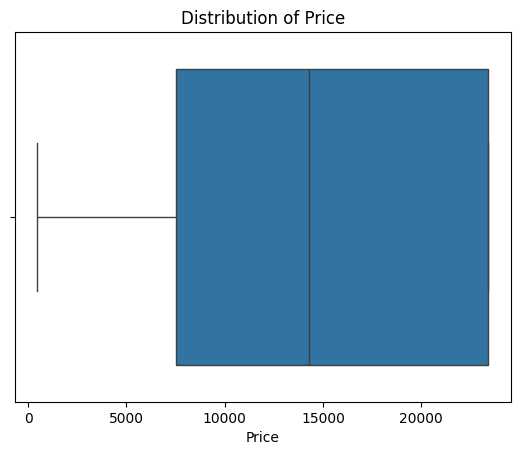

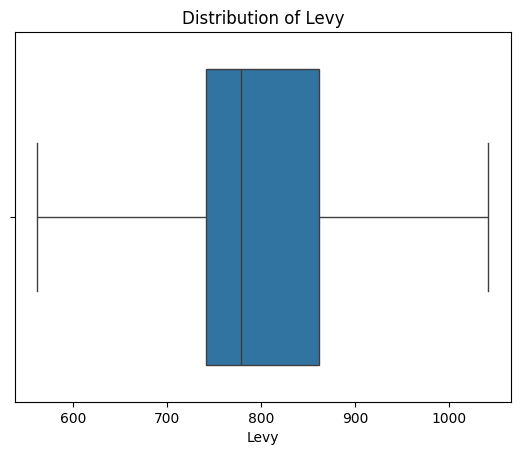

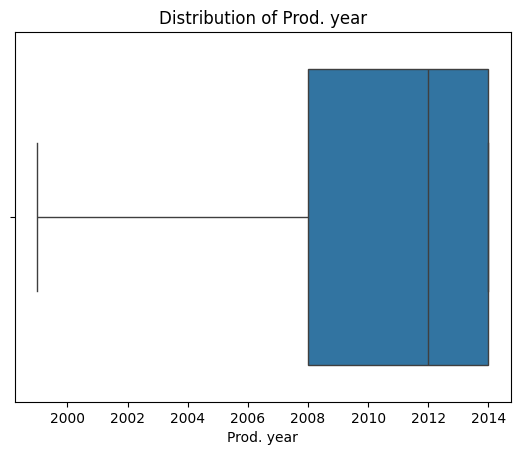

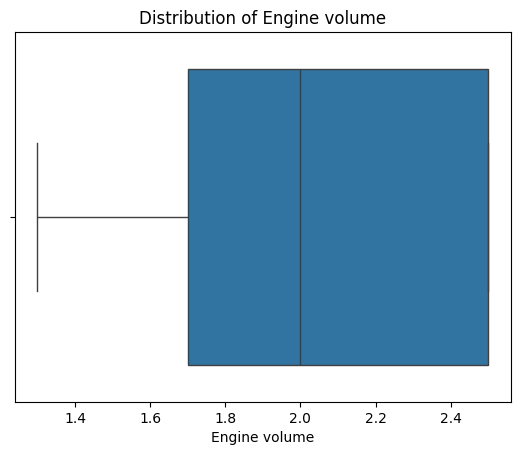

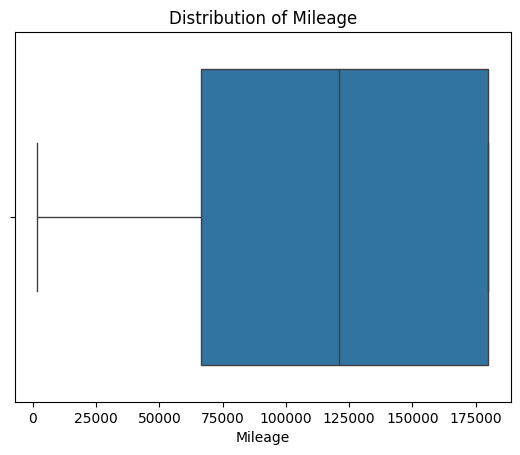

In [ ]:
for i in num_cols:
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(f'Distribution of {i}')
    plt.show()

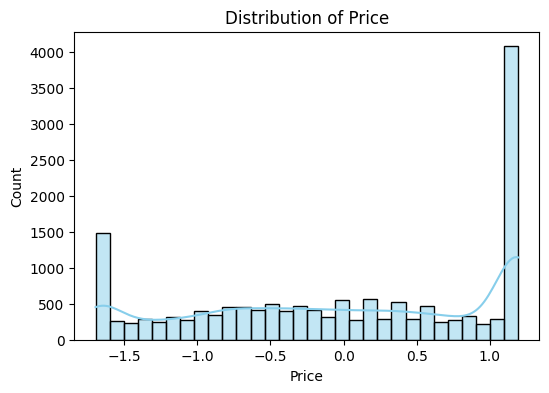

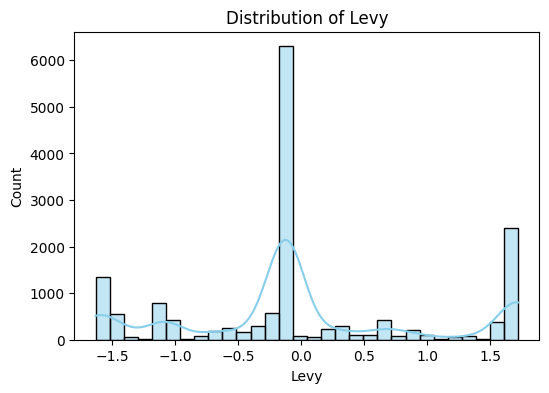

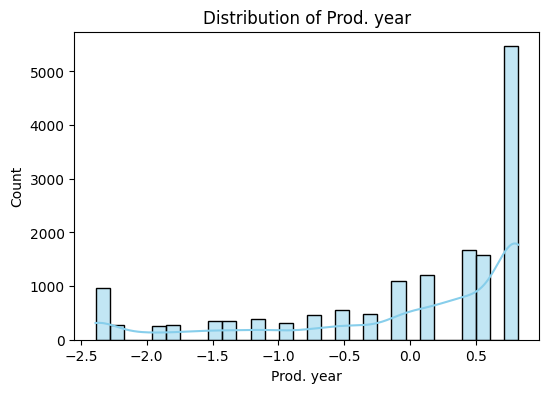

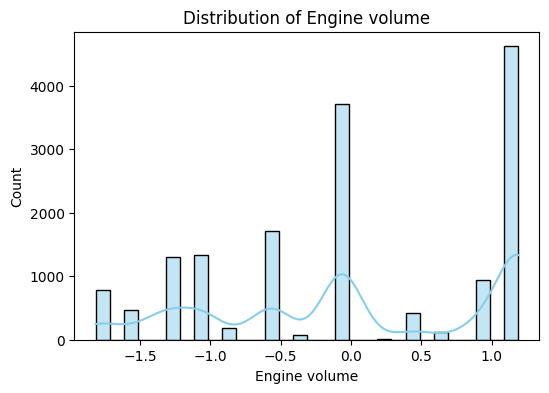

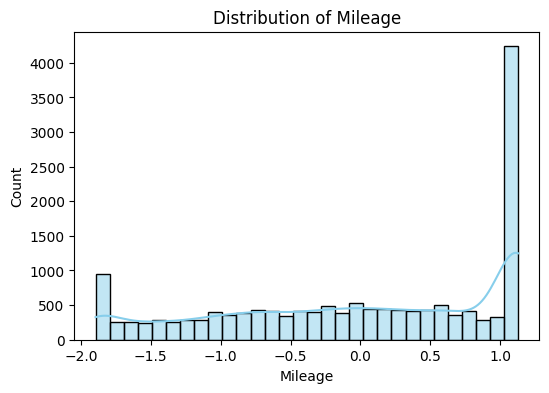

In [96]:
for i in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {i}')
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.show()

In [76]:
df = df.drop("IQR_Outlier",axis=1)

Encoding

In [77]:
cat_cols = df.select_dtypes(include='object').columns

In [78]:

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)
df = df.drop(cat_cols, axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [79]:
df = df.fillna(0)

Scaling

In [80]:
scaler = StandardScaler()

# fit on the numeric columns and transform
df[num_cols] = scaler.fit_transform(df[num_cols])

print(df[num_cols].head())

      Price      Levy  Prod. year  Engine volume   Mileage
0 -0.075696  1.723158   -0.035530       1.189938  1.129080
1  0.339495  1.555331    0.178387       1.189938  1.129080
2 -0.688584 -0.115955   -0.891196      -1.816261  1.129080
3 -1.301346  0.464450    0.178387       1.189938  0.941865
4 -0.277680 -1.633397    0.820136      -1.816261 -0.365707


Modeling

In [81]:
X = df.drop("Price", axis=1)   # features
y = df["Price"]               # target

In [82]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [83]:
dt_pipeline = Pipeline(steps=[
    ('Regressorr', DecisionTreeRegressor(min_samples_leaf=5,random_state=42))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred_dt)
mae = mean_absolute_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Results:")
print("MSE:", mse)
print("MAE:", mae)
print("R2 score:", r2)

Decision Tree Regressor Results:
MSE: 0.6152108908299277
MAE: 0.5132442654743723
R2 score: 0.3927840681491377


In [ ]:
rf_pipeline = Pipeline(steps=[
    ('Regressorr', RandomForestRegressor(
        n_estimators=100,       
        max_depth=7,            
        min_samples_leaf=5,     
        random_state=42
    ))
])


rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)


mse = mean_squared_error(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results:")
print("MSE:", mse)
print("MAE:", mae)
print("R2 score:", r2)

Random Forest Regressor Results:
MSE: 0.5588831004821351
MAE: 0.5482284943305654
R2 score: 0.44837985199326713


In [95]:
gb_pipeline = Pipeline(steps=[
    ('Regressorr', GradientBoostingRegressor(
        n_estimators=1000,      
        learning_rate=0.1,     
        max_depth=4,          
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred_gb)
mae = mean_absolute_error(y_test, y_pred_gb)
r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor Results:")
print("MSE:", mse)
print("MAE:", mae)
print("R2 score:", r2)

Gradient Boosting Regressor Results:
MSE: 0.4536320754726695
MAE: 0.4698287941829487
R2 score: 0.5522630897284857
